In [56]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

In [57]:
# Config settings

PRIMARY = "#F5A623"   # Thriveworks gold/amber
SECONDARY = "#2C3E50"   # Dark blue-grey
ACCENT1 = "#E8830C"   # Deep amber
ACCENT2 = "#FDD78C"   # Light gold
ACCENT3 = "#4A90D9"   # Blue accent
LIGHT_BG = "#FDFAF4"   # Warm off-white background
GRAY = "#B0B0B0"
DS1_COLOR = PRIMARY
DS2_COLOR = ACCENT3

plt.rcParams.update({
    "figure.facecolor": LIGHT_BG,
    "axes.facecolor": LIGHT_BG,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelcolor": SECONDARY,
    "axes.titlecolor": SECONDARY,
    "xtick.color": SECONDARY,
    "ytick.color": SECONDARY,
    "font.family": "DejaVu Sans",
    "font.size": 10,
})

In [58]:
# Load Data
df = pd.read_csv("../../data/DataAppointment_clean.csv")
df["ServiceDate"] = pd.to_datetime(df["ServiceDate"])
df = df.sort_values("ServiceDate").reset_index(drop=True)
df["YearMonth"] = df["ServiceDate"].dt.to_period("M")

In [59]:
# Aggregations

total_records = len(df)
ds_counts = df["Datasource"].value_counts().sort_index()
unique_users = df["UserID"].nunique()
total_revenue = df["Revenue"].sum()
min_date = df["ServiceDate"].min().strftime("%Y-%m-%d")
max_date = df["ServiceDate"].max().strftime("%Y-%m-%d")

monthly = df.groupby("YearMonth").agg(
    sessions = ("AppointmentID","count"),
    revenue = ("Revenue","sum"),
    unique_usr = ("UserID","nunique"),
).reset_index()
monthly["dt"] = monthly["YearMonth"].dt.to_timestamp()

monthly_ds = df.groupby(["YearMonth","Datasource"]).agg(
    sessions = ("AppointmentID","count"),
    revenue  = ("Revenue","sum"),
).reset_index()
monthly_ds["dt"] = monthly_ds["YearMonth"].dt.to_timestamp()

ds1 = monthly_ds[monthly_ds["Datasource"]==1]
ds2 = monthly_ds[monthly_ds["Datasource"]==2]

In [60]:
# Print results
print("=" * 55)
print("  THRIVEWORKS — KEY RESULTS SUMMARY")
print("=" * 55)
print(f"  Total Records      : {total_records:,}")
print(f"  Datasource 1       : {ds_counts.get(1,0):,}")
print(f"  Datasource 2       : {ds_counts.get(2,0):,}")
print(f"  Unique Users       : {unique_users:,}")
print(f"  Total Revenue      : ${total_revenue:,.2f}")
print(f"  Min Service Date   : {min_date}")
print(f"  Max Service Date   : {max_date}")

  THRIVEWORKS — KEY RESULTS SUMMARY
  Total Records      : 17,294
  Datasource 1       : 11,367
  Datasource 2       : 5,927
  Unique Users       : 1,419
  Total Revenue      : $2,833,844.12
  Min Service Date   : 2024-03-29
  Max Service Date   : 2025-11-30


In [61]:
# Monthly summary
print("─" * 55)
print("  MONTHLY SESSIONS & REVENUE")
print("─" * 55)
print(monthly[["YearMonth","sessions","revenue","unique_usr"]].to_string(index=False))

───────────────────────────────────────────────────────
  MONTHLY SESSIONS & REVENUE
───────────────────────────────────────────────────────
YearMonth  sessions       revenue  unique_usr
  2024-03         1    185.000000           1
  2024-04        10   1850.000000          10
  2024-05      2874 489861.663025        1393
  2024-06      2642 424674.890000        1019
  2024-07      1992 318793.630000         757
  2024-08      1503 240693.460000         585
  2024-09      1117 179750.130000         460
  2024-10       994 160889.990000         382
  2024-11       699 113201.620000         325
  2024-12       650 106210.810000         292
  2025-01       690 114222.190000         279
  2025-02       543  89606.760000         239
  2025-03       565  93372.830000         238
  2025-04       496  81748.990000         220
  2025-05       449  73575.760000         200
  2025-06       392  65006.580000         187
  2025-07       367  61636.980000         165
  2025-08       325  54060.7300

In [62]:
# Task 2: Group by
target_ids = [108, 224, 842, 416, 889, 1019]

# Filter for target IDs
target_df = df[df['UserID'].isin(target_ids)].copy()

# Find the 1st Service Date per User
target_df['First_Date'] = target_df.groupby('UserID')['ServiceDate'].transform('min')

first_appointments = target_df[target_df['ServiceDate'] == target_df['First_Date']].copy()
step2_output = first_appointments[['UserID', 'First_Date', 'AppointmentID', 'Revenue']].copy()
step2_output.columns = ['UserID', '1st Service Date', 'Appointment ID', 'Revenue']

In [63]:
step2_output = step2_output.sort_values('UserID').reset_index(drop=True)
step2_output

,UserID,1st Service Date,Appointment ID,Revenue
0,108,2024-05-11,26,158.000000
1,108,2024-05-11,27,50.000000
2,224,2024-05-07,134,50.000000
3,224,2024-05-07,133,160.660476
4,416,2024-05-08,395,195.058515
5,842,2024-05-13,1739,187.084630
6,889,2024-05-14,1890,195.667000
7,1019,2024-05-17,2344,50.000000
8,1019,2024-05-17,2343,204.951754


In [64]:
# TASK 3: Sort by Service Date (Ascending)
step3_output = step2_output.sort_values('1st Service Date').reset_index(drop=True)
step3_output

,UserID,1st Service Date,Appointment ID,Revenue
0,224,2024-05-07,134,50.000000
1,224,2024-05-07,133,160.660476
2,416,2024-05-08,395,195.058515
3,108,2024-05-11,26,158.000000
4,108,2024-05-11,27,50.000000
5,842,2024-05-13,1739,187.084630
6,889,2024-05-14,1890,195.667000
7,1019,2024-05-17,2344,50.000000
8,1019,2024-05-17,2343,204.951754


In [65]:
# LTV WATERFALL
user_first = df.groupby("UserID")["ServiceDate"].min().rename("FirstDate")
df = df.join(user_first, on="UserID")
df["MonthsSinceFirst"] = (
    (df["ServiceDate"].dt.year  - df["FirstDate"].dt.year) * 12 +
    (df["ServiceDate"].dt.month - df["FirstDate"].dt.month)
)
df

,Revenue,UserID,AppointmentID,Datasource,ServiceDate,YearMonth,FirstDate,MonthsSinceFirst
0,185.00,64,1,1,2024-03-29,2024-03,2024-03-29,0
1,185.00,73,2,1,2024-04-12,2024-04,2024-04-12,0
2,185.00,98,18,1,2024-04-19,2024-04,2024-04-19,0
3,185.00,81,6,1,2024-04-22,2024-04,2024-04-22,0
4,185.00,79,4,1,2024-04-23,2024-04,2024-04-23,0
...,...,...,...,...,...,...,...,...
17289,159.09,709,17273,2,2025-11-28,2025-11,2024-05-11,18
17290,180.25,978,17290,2,2025-11-28,2025-11,2024-05-27,18
17291,166.01,745,16752,2,2025-11-29,2025-11,2024-05-11,18
17292,214.89,280,17130,2,2025-11-30,2025-11,2024-05-04,18


In [66]:
ltv = df.groupby("MonthsSinceFirst").agg(
    sessions = ("AppointmentID","count"),
    revenue = ("Revenue","sum"),
    unique_users = ("UserID","nunique"),
).reset_index()
ltv["cum_revenue"] = ltv["revenue"].cumsum()
ltv["cum_sessions"] = ltv["sessions"].cumsum()
ltv["avg_rev_ses"] = ltv["revenue"] / ltv["sessions"]
total_users = unique_users
ltv["retention_pct"] = ltv["unique_users"] / total_users * 100

ltv

,MonthsSinceFirst,sessions,revenue,unique_users,cum_revenue,cum_sessions,avg_rev_ses,retention_pct
0,0,2909,496059.776941,1419,4.960598e+05,2909,170.525877,100.000000
1,1,2674,430057.386575,1027,9.261172e+05,5583,160.829240,72.374912
2,2,2001,320450.389509,765,1.246568e+06,7584,160.145122,53.911205
3,3,1512,242123.800000,586,1.488691e+06,9096,160.134788,41.296688
4,4,1117,179937.870000,459,1.668629e+06,10213,161.090304,32.346723
5,5,975,157671.810000,378,1.826301e+06,11188,161.714677,26.638478
6,6,709,114721.850000,326,1.941023e+06,11897,161.807969,22.973925
7,7,650,106376.690000,294,2.047400e+06,12547,163.656446,20.718816
8,8,689,114241.770000,278,2.161641e+06,13236,165.808084,19.591261
9,9,550,90864.170000,239,2.252506e+06,13786,165.207582,16.842847


In [67]:
total_users

1419

In [ ]:
# LTV WATERFALL
user_first = df.groupby("UserID")["ServiceDate"].min().rename("FirstDate")
df = df.join(user_first, on="UserID")
df["MonthsSinceFirst"] = (
    (df["ServiceDate"].dt.year  - df["FirstDate"].dt.year) * 12 +
    (df["ServiceDate"].dt.month - df["FirstDate"].dt.month)
)

ltv = df.groupby("MonthsSinceFirst").agg(
    sessions = ("AppointmentID","count"),
    revenue = ("Revenue","sum"),
    unique_users = ("UserID","nunique"),
).reset_index()
ltv["cum_revenue"] = ltv["revenue"].cumsum()
ltv["cum_sessions"] = ltv["sessions"].cumsum()
ltv["avg_rev_ses"] = ltv["revenue"] / ltv["sessions"]
total_users = unique_users
ltv["retention_pct"] = ltv["unique_users"] / total_users * 100

avg_ltv = total_revenue / unique_users
avg_sessions_user = total_records / unique_users

print()
print("─" * 55)
print("  LTV WATERFALL (first 18 months)")
print("─" * 55)
ltv_show = ltv[ltv["MonthsSinceFirst"] <= 18].copy()
print(ltv_show[[
    "MonthsSinceFirst","sessions","revenue",
    "cum_revenue","unique_users","retention_pct"
]].round(2).to_string(index=False))
print()
print(f"  Avg LTV per patient   : ${avg_ltv:,.2f}")
print(f"  Avg sessions/patient  : {avg_sessions_user:.2f}")


───────────────────────────────────────────────────────
  LTV WATERFALL (first 18 months)
───────────────────────────────────────────────────────
 MonthsSinceFirst  sessions   revenue  cum_revenue  unique_users  retention_pct
                0      2909 496059.78    496059.78          1419         100.00
                1      2674 430057.39    926117.16          1027          72.37
                2      2001 320450.39   1246567.55           765          53.91
                3      1512 242123.80   1488691.35           586          41.30
                4      1117 179937.87   1668629.22           459          32.35
                5       975 157671.81   1826301.03           378          26.64
                6       709 114721.85   1941022.88           326          22.97
                7       650 106376.69   2047399.57           294          20.72
                8       689 114241.77   2161641.34           278          19.59
                9       550  90864.17   2252505.51   

In [11]:
## DEC 2025 FORECAST
# Use 3-month rolling average run-rate (Sep, Oct, Nov 2025)
last3 = monthly[monthly["YearMonth"].isin([
    pd.Period("2025-09","M"),
    pd.Period("2025-10","M"),
    pd.Period("2025-11","M"),
])]
run_rate_3m = last3["sessions"].mean()

# Also apply seasonal Dec/Nov ratio from 2024
dec24 = monthly.loc[monthly["YearMonth"]==pd.Period("2024-12","M"), "sessions"].values[0]
nov24 = monthly.loc[monthly["YearMonth"]==pd.Period("2024-11","M"), "sessions"].values[0]
seasonal_ratio = dec24 / nov24
nov25_sessions = monthly.loc[monthly["YearMonth"]==pd.Period("2025-11","M"), "sessions"].values[0]
dec25_seasonal = int(nov25_sessions * seasonal_ratio)
dec25_runrate  = int(run_rate_3m)

# Blended forecast (average of two methods)
dec25_forecast = int((dec25_seasonal + dec25_runrate) / 2)

print()
print("─" * 55)
print("  DEC 2025 FORECAST")
print("─" * 55)
print(f"  Nov 2025 actual sessions     : {nov25_sessions}")
print(f"  Run-rate (3-mo avg) forecast : {dec25_runrate}")
print(f"  Seasonal-adjusted forecast   : {dec25_seasonal}")
print(f"  Blended forecast (avg)       : {dec25_forecast}")
print()


───────────────────────────────────────────────────────
  DEC 2025 FORECAST
───────────────────────────────────────────────────────
  Nov 2025 actual sessions     : 290
  Run-rate (3-mo avg) forecast : 328
  Seasonal-adjusted forecast   : 269
  Blended forecast (avg)       : 298



In [12]:
# Build forecast time series
forecast_monthly = monthly.copy()
dec25_row = pd.DataFrame([{
    "YearMonth"  : pd.Period("2025-12","M"),
    "sessions"   : dec25_forecast,
    "revenue"    : dec25_forecast * monthly["revenue"].div(monthly["sessions"]).iloc[-6:].mean(),
    "unique_usr" : np.nan,
    "dt"         : pd.Timestamp("2025-12-01"),
    "forecast"   : True,
}])
forecast_monthly["forecast"] = False
forecast_df = pd.concat([forecast_monthly, dec25_row], ignore_index=True)

print("  Full monthly time-series + Dec 2025 forecast:")
print(forecast_df[["YearMonth","sessions","forecast"]].to_string(index=False))


  Full monthly time-series + Dec 2025 forecast:
YearMonth  sessions  forecast
  2024-03         1     False
  2024-04        10     False
  2024-05      2874     False
  2024-06      2642     False
  2024-07      1992     False
  2024-08      1503     False
  2024-09      1117     False
  2024-10       994     False
  2024-11       699     False
  2024-12       650     False
  2025-01       690     False
  2025-02       543     False
  2025-03       565     False
  2025-04       496     False
  2025-05       449     False
  2025-06       392     False
  2025-07       367     False
  2025-08       325     False
  2025-09       343     False
  2025-10       352     False
  2025-11       290     False
  2025-12       298      True


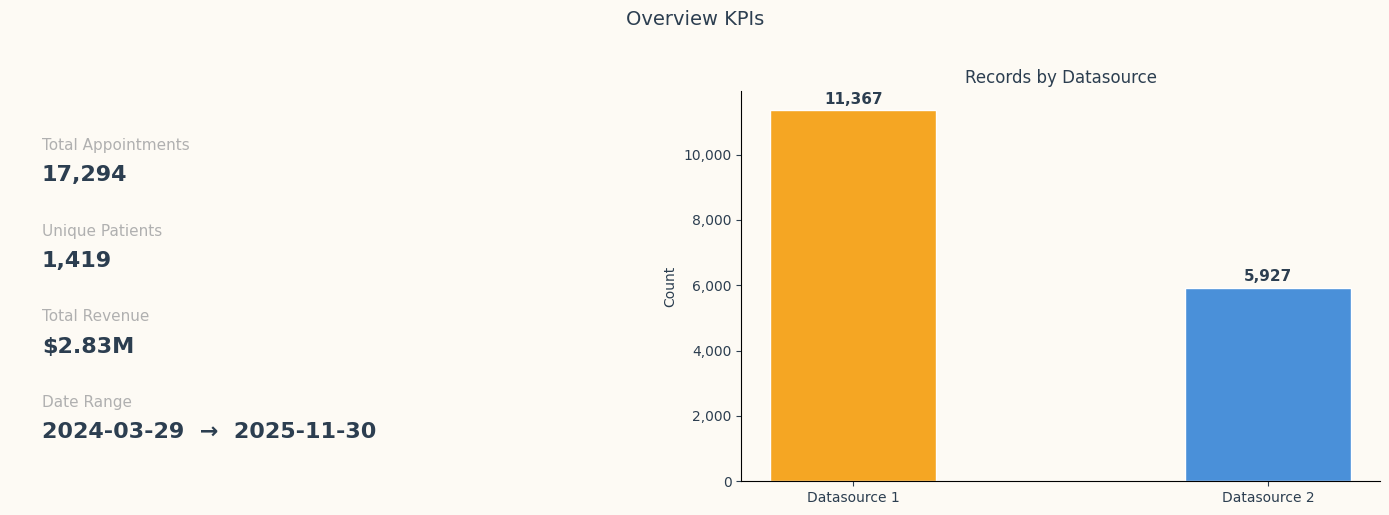

In [35]:
# PLOT: KPI Cards
# ─────────────────────────────────────────────
fig2, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=LIGHT_BG)
fig2.suptitle("Overview KPIs", fontsize=14, color=SECONDARY, y=1.02)

# Left: KPI text cards (simulated)
ax_kpi = axes[0]
ax_kpi.axis("off")
kpis = [
    ("Total Appointments", f"{total_records:,}"),
    ("Unique Patients",    f"{unique_users:,}"),
    ("Total Revenue",      f"${total_revenue/1e6:.2f}M"),
    ("Date Range",         f"{min_date}  →  {max_date}"),
]
for i, (label, val) in enumerate(kpis):
    y_pos = 0.85 - i * 0.22
    ax_kpi.text(0.05, y_pos, label, fontsize=11, color=GRAY, transform=ax_kpi.transAxes)
    ax_kpi.text(0.05, y_pos - 0.08, val, fontsize=16, fontweight="bold",
                color=SECONDARY, transform=ax_kpi.transAxes)

# Right: Datasource bar chart
ax_bar = axes[1]
bars = ax_bar.bar(
    ["Datasource 1", "Datasource 2"],
    [ds_counts.get(1,0), ds_counts.get(2,0)],
    color=[DS1_COLOR, DS2_COLOR], width=0.4, edgecolor="white"
)
for bar in bars:
    ax_bar.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                f"{int(bar.get_height()):,}", ha="center", va="bottom",
                fontsize=11, color=SECONDARY, fontweight="bold")
ax_bar.set_title("Records by Datasource", color=SECONDARY)
ax_bar.set_ylabel("Count")
ax_bar.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))

plt.tight_layout()

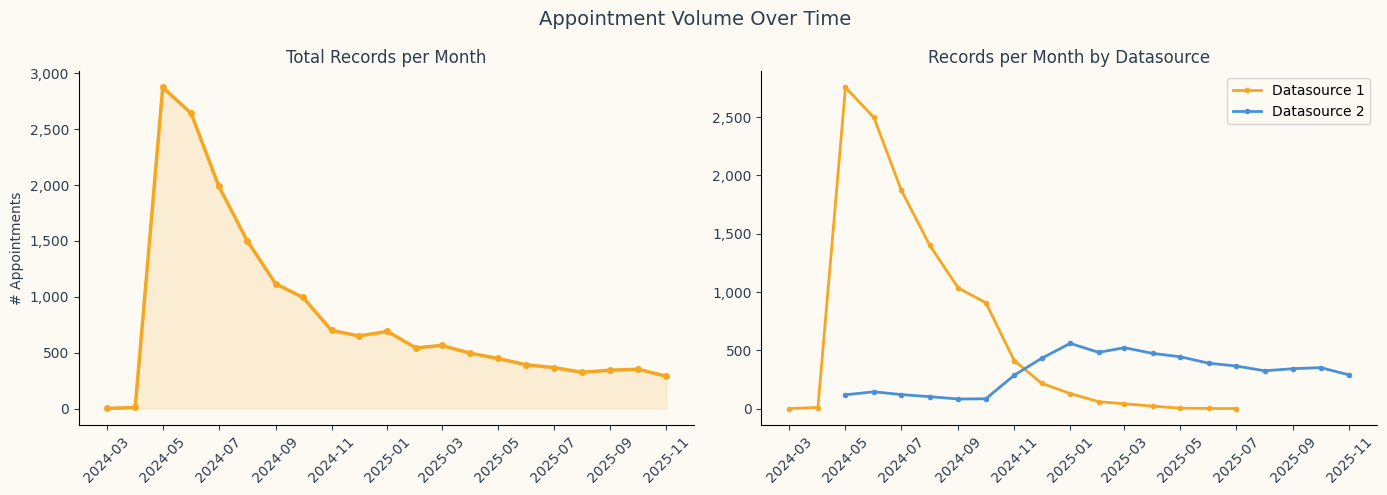

In [34]:
# PLOT: Records over time
# ─────────────────────────────────────────────
fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor=LIGHT_BG)
fig3.suptitle("Appointment Volume Over Time", fontsize=14, color=SECONDARY)

ax1.plot(monthly["dt"], monthly["sessions"], color=PRIMARY, linewidth=2.5, marker="o", markersize=4)
ax1.fill_between(monthly["dt"], monthly["sessions"], alpha=0.15, color=PRIMARY)
ax1.set_title("Total Records per Month")
ax1.set_ylabel("# Appointments")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
ax1.tick_params(axis="x", rotation=45)

for ds, color, label in [(1, DS1_COLOR, "Datasource 1"), (2, DS2_COLOR, "Datasource 2")]:
    d = monthly_ds[monthly_ds["Datasource"]==ds]
    ax2.plot(d["dt"], d["sessions"], color=color, linewidth=2, marker="o", markersize=3, label=label)
ax2.set_title("Records per Month by Datasource")
ax2.legend()
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

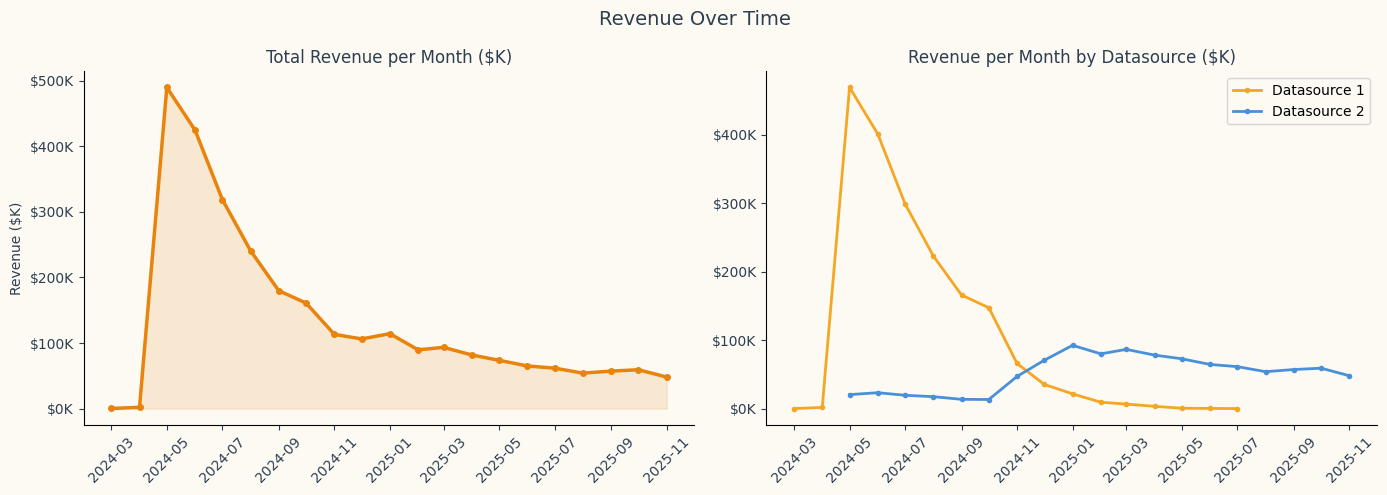

In [33]:
# PLOT: Revenue over time
# ─────────────────────────────────────────────
fig4, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor=LIGHT_BG)
fig4.suptitle("Revenue Over Time", fontsize=14, color=SECONDARY)

ax1.plot(monthly["dt"], monthly["revenue"]/1e3, color=ACCENT1, linewidth=2.5, marker="o", markersize=4)
ax1.fill_between(monthly["dt"], monthly["revenue"]/1e3, alpha=0.15, color=ACCENT1)
ax1.set_title("Total Revenue per Month ($K)")
ax1.set_ylabel("Revenue ($K)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}K"))
ax1.tick_params(axis="x", rotation=45)

for ds, color, label in [(1, DS1_COLOR, "Datasource 1"), (2, DS2_COLOR, "Datasource 2")]:
    d = monthly_ds[monthly_ds["Datasource"]==ds]
    ax2.plot(d["dt"], d["revenue"]/1e3, color=color, linewidth=2, marker="o", markersize=3, label=label)
ax2.set_title("Revenue per Month by Datasource ($K)")
ax2.legend()
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}K"))
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

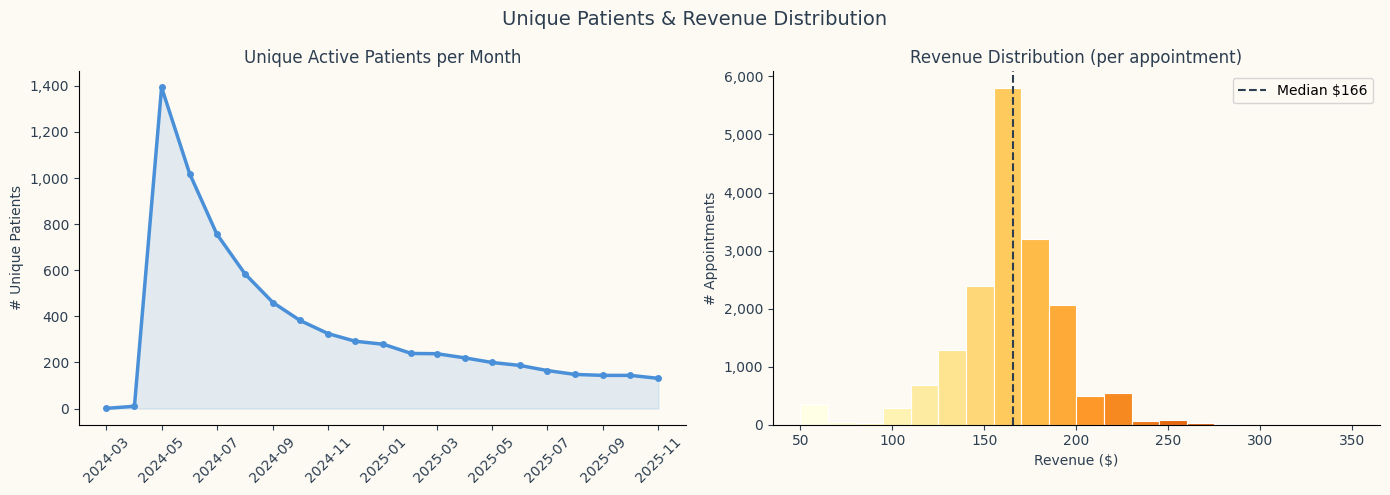

In [32]:
# PLOT: Unique Users + Revenue Histogram
# ─────────────────────────────────────────────
fig5, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor=LIGHT_BG)
fig5.suptitle("Unique Patients & Revenue Distribution", fontsize=14, color=SECONDARY)

ax1.plot(monthly["dt"], monthly["unique_usr"], color=ACCENT3, linewidth=2.5, marker="o", markersize=4)
ax1.fill_between(monthly["dt"], monthly["unique_usr"], alpha=0.15, color=ACCENT3)
ax1.set_title("Unique Active Patients per Month")
ax1.set_ylabel("# Unique Patients")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
ax1.tick_params(axis="x", rotation=45)

# Revenue histogram — 20 bins looks clean
n, bins, patches = ax2.hist(df["Revenue"], bins=20, color=PRIMARY,
                             edgecolor="white", linewidth=0.8)
# Colour-code by range
norm = plt.Normalize(df["Revenue"].min(), df["Revenue"].max())
for patch, left in zip(patches, bins[:-1]):
    patch.set_facecolor(plt.cm.YlOrBr(norm(left)))
ax2.set_title("Revenue Distribution (per appointment)")
ax2.set_xlabel("Revenue ($)")
ax2.set_ylabel("# Appointments")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
# Median line
median_rev = df["Revenue"].median()
ax2.axvline(median_rev, color=SECONDARY, linestyle="--", linewidth=1.5,
            label=f"Median ${median_rev:.0f}")
ax2.legend()

plt.tight_layout()
plt.show()

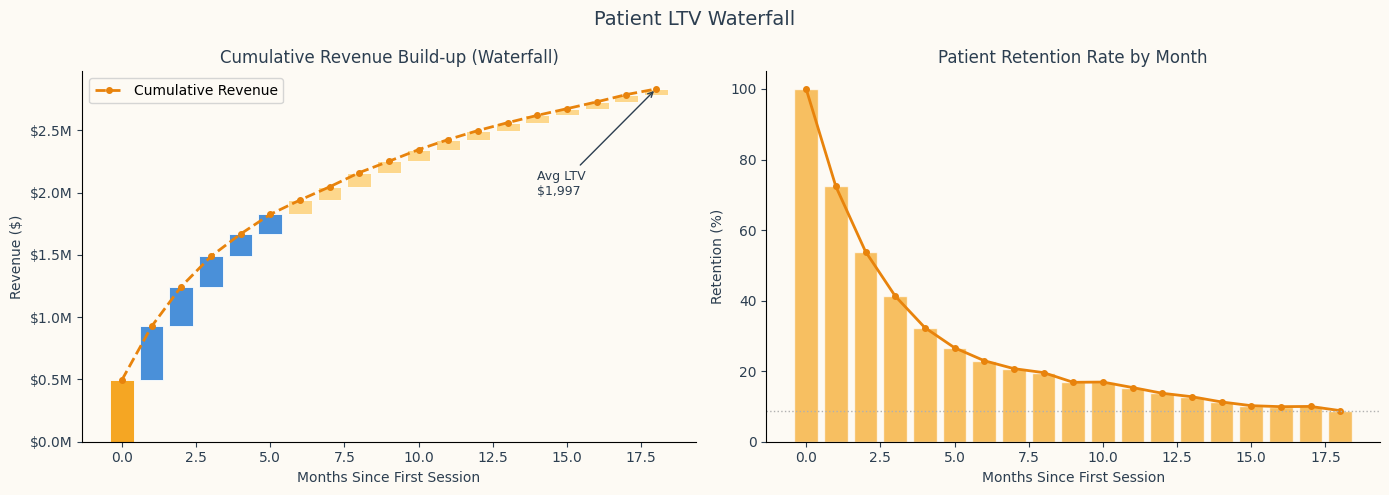

In [31]:
# PLOT: LTV Waterfall
# ─────────────────────────────────────────────
ltv_plot = ltv[ltv["MonthsSinceFirst"] <= 18].copy()
fig7, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor=LIGHT_BG)
fig7.suptitle("Patient LTV Waterfall", fontsize=14, color=SECONDARY)

# Waterfall: cumulative revenue build-up
months = ltv_plot["MonthsSinceFirst"].tolist()
revenues = ltv_plot["revenue"].tolist()
cum_rev = ltv_plot["cum_revenue"].tolist()

running = 0
for i, (m, rev) in enumerate(zip(months, revenues)):
    color = PRIMARY if i == 0 else (ACCENT3 if rev > np.mean(revenues) else ACCENT2)
    ax1.bar(m, rev, bottom=running, color=color, edgecolor="white", linewidth=0.6)
    running += rev

ax1.plot(months, cum_rev, color=ACCENT1, linewidth=2, linestyle="--",
         marker="o", markersize=4, label="Cumulative Revenue")
ax1.set_title("Cumulative Revenue Build-up (Waterfall)")
ax1.set_xlabel("Months Since First Session")
ax1.set_ylabel("Revenue ($)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1e6:.1f}M"))
ax1.legend()

# Retention curve
ax2.bar(ltv_plot["MonthsSinceFirst"], ltv_plot["retention_pct"],
        color=PRIMARY, edgecolor="white", alpha=0.7)
ax2.plot(ltv_plot["MonthsSinceFirst"], ltv_plot["retention_pct"],
         color=ACCENT1, linewidth=2, marker="o", markersize=4)
ax2.set_title("Patient Retention Rate by Month")
ax2.set_xlabel("Months Since First Session")
ax2.set_ylabel("Retention (%)")
ax2.axhline(ltv_plot["retention_pct"].iloc[-1], color=GRAY,
            linestyle=":", linewidth=1)

# Annotate avg LTV
ax1.annotate(f"Avg LTV\n${avg_ltv:,.0f}",
             xy=(18, ltv_plot["cum_revenue"].iloc[-1]),
             xytext=(14, ltv_plot["cum_revenue"].iloc[-1]*0.7),
             arrowprops=dict(arrowstyle="->", color=SECONDARY),
             color=SECONDARY, fontsize=9)

plt.tight_layout()
plt.show()

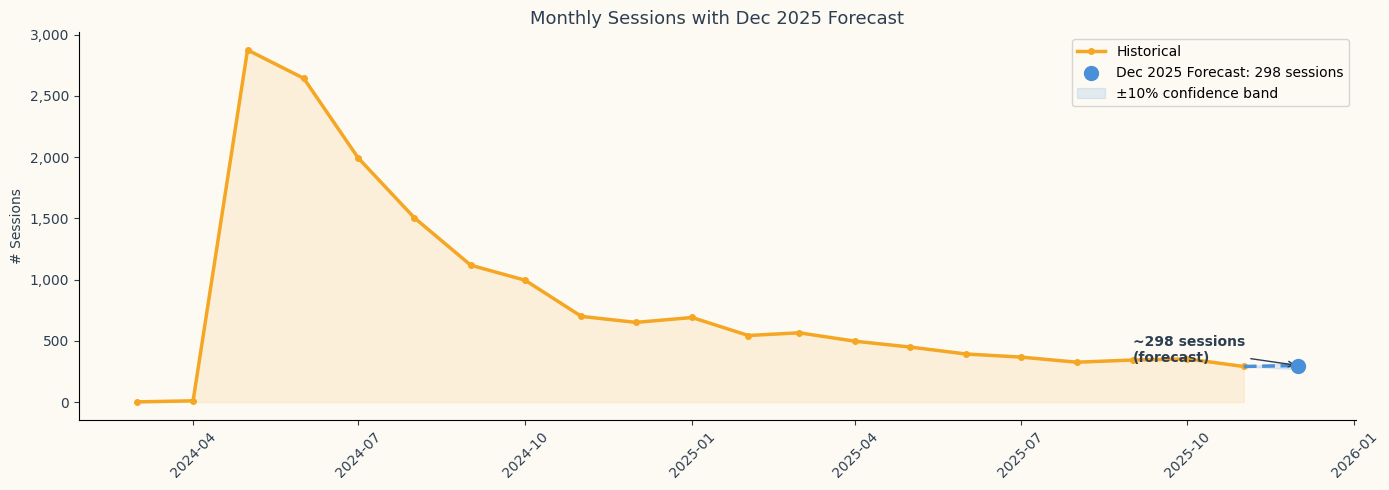

In [ ]:
# Plot - Forecast Dec2015
fig9, ax = plt.subplots(figsize=(14, 5), facecolor=LIGHT_BG)

# Historical (exclude early outliers May 2024 spikes for clarity — keep all)
hist = forecast_df[~forecast_df["forecast"]]
fcast = forecast_df[forecast_df["forecast"]]

ax.plot(hist["dt"], hist["sessions"], color=PRIMARY, linewidth=2.5,
        marker="o", markersize=4, label="Historical")
ax.fill_between(hist["dt"], hist["sessions"], alpha=0.12, color=PRIMARY)

# Forecast point
last_hist_dt = hist["dt"].iloc[-1]
last_hist_val = hist["sessions"].iloc[-1]
ax.plot([last_hist_dt, fcast["dt"].iloc[0]],
        [last_hist_val, fcast["sessions"].iloc[0]],
        color=ACCENT3, linewidth=2.5, linestyle="--")
ax.scatter(fcast["dt"], fcast["sessions"], color=ACCENT3, s=100, zorder=5,
           label=f"Dec 2025 Forecast: {dec25_forecast} sessions")

# Confidence band ±10%
low  = dec25_forecast * 0.90
high = dec25_forecast * 1.10
ax.fill_between([last_hist_dt, fcast["dt"].iloc[0]],
                [last_hist_val, low],
                [last_hist_val, high],
                alpha=0.15, color=ACCENT3, label="±10% confidence band")

ax.annotate(f"~{dec25_forecast} sessions\n(forecast)",
            xy=(fcast["dt"].iloc[0], dec25_forecast),
            xytext=(fcast["dt"].iloc[0] - pd.DateOffset(months=3), dec25_forecast + 30),
            arrowprops=dict(arrowstyle="->", color=SECONDARY),
            color=SECONDARY, fontsize=10, fontweight="bold")

ax.set_title("Monthly Sessions with Dec 2025 Forecast", color=SECONDARY, fontsize=13)
ax.set_ylabel("# Sessions")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()